In [ ]:
# ============================================================
# HÜCRE 1 — Drive'ı bağla
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# HÜCRE 2 — Kütüphaneleri yükle (ilk çalıştırmada bir kez)
# ============================================================
# !pip install -q diffusers transformers accelerate safetensors


# ============================================================
# HÜCRE 3 — Model + LoRA yükle
# ============================================================
import torch
from diffusers import StableDiffusionPipeline

# ---- AYARLAR ----
MODEL_ID  = "runwayml/stable-diffusion-v1-5"
LORA_PATH = "/content/drive/MyDrive/celeba_lora/output_hq_10k/celeba_hq_lora-step00006000.safetensors"
CSV_PATH  = "/content/drive/MyDrive/dataset_complete_extended.csv"
# -----------------

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

pipe.load_lora_weights(LORA_PATH)
print("✅ Model + LoRA yüklendi!")




Mounted at /content/drive


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Loading weights:   0%|          | 0/144 [00:00<?, ?it/s]

✅ Model + LoRA yüklendi!


Kolon kontrol → positive: 'positive_prompt' | negative: 'negative_prompt'

[1/10] Üretiliyor...


Token indices sequence length is longer than the specified maximum sequence length for this model (102 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['wavy hair , fine hair , light freckles , large ears , attached earlobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

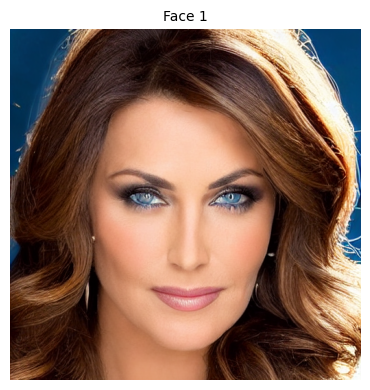


[2/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', thick hair , light freckles , attached earlobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

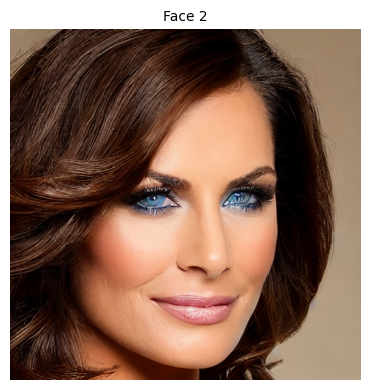


[3/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

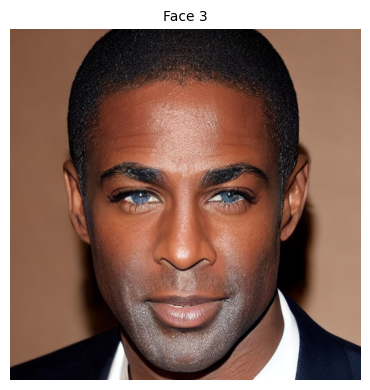


[4/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['large ears , attached earlobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

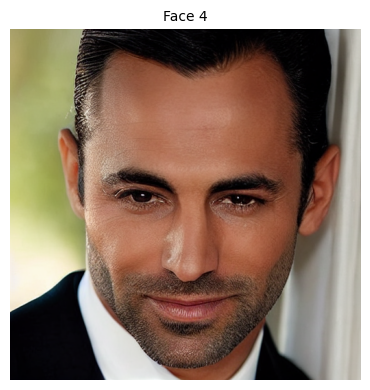


[5/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['earlobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

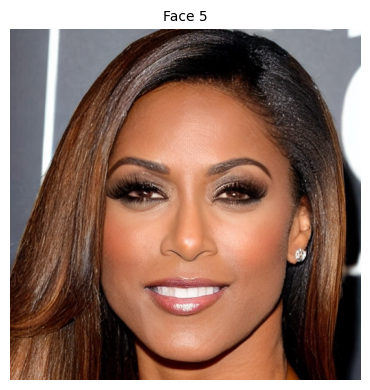


[6/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['earlobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

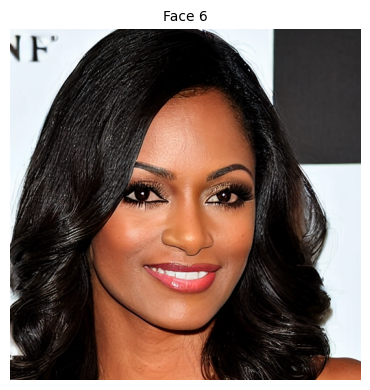


[7/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

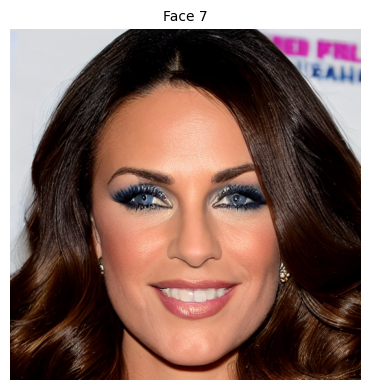


[8/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

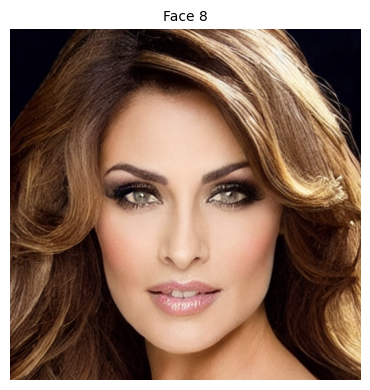


[9/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lobes , neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

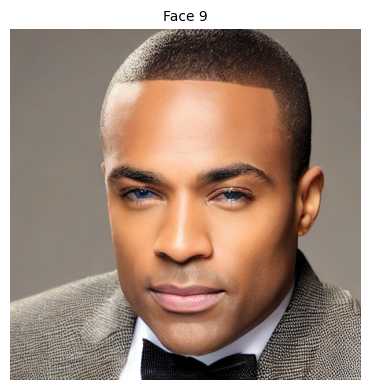


[10/10] Üretiliyor...


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['neutral expression , centered face , soft lighting , plain background']


  0%|          | 0/30 [00:00<?, ?it/s]

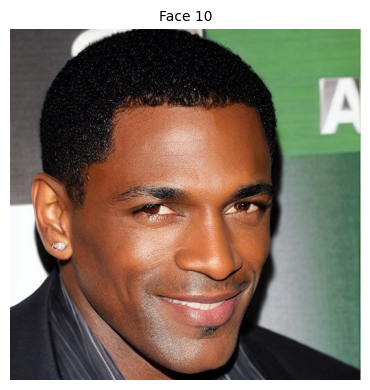


🎉 Bitti!


In [ ]:
# ============================================================
# HÜCRE 4 — CSV'den ilk 10 prompt'u çek ve inline göster
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import textwrap

df = pd.read_csv(CSV_PATH, nrows=10)
pos_col = df.columns[-2]
neg_col = df.columns[-1]

print(f"Kolon kontrol → positive: '{pos_col}' | negative: '{neg_col}'\n")

for i, row in df.iterrows():
    print(f"[{i+1}/10] Üretiliyor...")

    # Description yazdır
    prompt_text = row[pos_col]
    wrapped = textwrap.fill(prompt_text, width=90)
    display(HTML(f"""
        <div style="margin: 18px 0 6px 0; padding: 10px 14px;
                    background:#f5f5f5; border-left: 4px solid #888;
                    font-family: monospace; font-size: 13px; color: #333;">
            <b>Face {i+1} — Prompt:</b><br>{wrapped}
        </div>
    """))

    # Görsel üret
    image = pipe(
        prompt=prompt_text,
        negative_prompt=row[neg_col],
        num_inference_steps=30,
        guidance_scale=7.5,
        width=512,
        height=512,
        generator=torch.Generator("cuda").manual_seed(i),
    ).images[0]

    # Görseli inline göster
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image)
    ax.set_title(f"Face {i+1}", fontsize=10)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print()

print("🎉 Bitti!")

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', light freckles , large ears , attached earlobes , neutral expression , centered face , soft lighting , plain background']


Kolon kontrol → positive: 'positive_prompt' | negative: 'negative_prompt'

[1/1] Üretiliyor... (orijinal row: 10)


  0%|          | 0/30 [00:00<?, ?it/s]

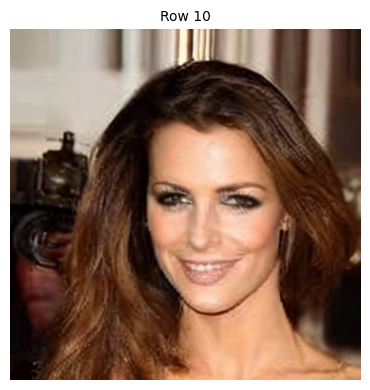

🎉 Bitti!


In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ---- AYARLAR ----
CSV_PATH  = "/content/drive/MyDrive/dataset_complete_extended.csv"
ROWS      = [10]   # ✏️ istediğin row indexlerini buraya yaz
# -----------------

df_full = pd.read_csv(CSV_PATH)
df = df_full.iloc[ROWS].reset_index(drop=True)

pos_col = df.columns[-2]
neg_col = df.columns[-1]

print(f"Kolon kontrol → positive: '{pos_col}' | negative: '{neg_col}'\n")

images = []
for i, row in df.iterrows():
    print(f"[{i+1}/{len(df)}] Üretiliyor... (orijinal row: {ROWS[i]})")
    image = pipe(
        prompt=row[pos_col],
        negative_prompt=row[neg_col],
        num_inference_steps=30,
        guidance_scale=7.5,
        width=512,
        height=512,
        generator=torch.Generator("cuda").manual_seed(ROWS[i]),
    ).images[0]
    images.append(image)

# Grid göster
n = len(images)
cols = min(n, 5)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = [axes] if n == 1 else axes.flatten()

for i, (ax, img) in enumerate(zip(axes, images)):
    ax.imshow(img)
    ax.set_title(f"Row {ROWS[i]}", fontsize=10)
    ax.axis("off")

# boş hücreleri gizle
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
print("🎉 Bitti!")

In [ ]:
# ============================================================
# HÜCRE 1 — Drive'ı bağla
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# HÜCRE 2 — Kütüphaneleri yükle (ilk çalıştırmada bir kez)
# ============================================================
# !pip install -q diffusers transformers accelerate safetensors


# ============================================================
# HÜCRE 3 — Model + LoRA yükle
# ============================================================
import torch
from diffusers import StableDiffusionPipeline

# ---- AYARLAR (sadece burayı değiştir) ----
MODEL_ID   = "runwayml/stable-diffusion-v1-5"
LORA_PATH  = "/content/drive/MyDrive/celeba_lora/output/celeba_lora.safetensors"
CSV_PATH   = "/content/drive/MyDrive/dataset_complete_extended.csv"   # CSV de Drive'daysa
OUTPUT_DIR = "/content/drive/MyDrive/celeba_lora/inference_outputs"       # çıktılar Drive'a gitsin
# ------------------------------------------

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
).to("cuda")

pipe.load_lora_weights(LORA_PATH)
print("✅ Model + LoRA yüklendi!")


# ============================================================
# HÜCRE 4 — CSV'den ilk 10 prompt'u çek ve üret
# ============================================================
import pandas as pd
from IPython.display import display, Image as IPImage

df = pd.read_csv(CSV_PATH, nrows=10)

# En son 2 kolon: positive_prompt ve negative_prompt
pos_col = df.columns[-2]   # positive_prompt
neg_col = df.columns[-1]   # negative_prompt

print(f"Kolon kontrol → positive: '{pos_col}' | negative: '{neg_col}'\n")

for i, row in df.iterrows():
    pos = row[pos_col]
    neg = row[neg_col]

    print(f"[{i+1}/10] Üretiliyor...")
    print(f"  Prompt: {pos[:80]}...")   # kısa önizleme

    image = pipe(
        prompt=pos,
        negative_prompt=neg,
        num_inference_steps=30,
        guidance_scale=7.5,
        width=512,
        height=512,
        generator=torch.Generator("cuda").manual_seed(i),  # tekrar üretilebilir sonuç
    ).images[0]

    filename = os.path.join(OUTPUT_DIR, f"face_{i+1:02d}.png")
    image.save(filename)

    # Colab'da inline göster
    display(IPImage(filename))
    print(f"  ✅ Kaydedildi: {filename}\n")

print("🎉 Bitti! Tüm görseller Drive'a kaydedildi.")

MessageError: Error: credential propagation was unsuccessful